<h1>AI-Based Resume Screening System</h1>

In [1]:
!pip install PyPDF2 
!pip install python-docx


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import PyPDF2
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import docx
import os


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from PyPDF2 import PdfReader
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [4]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
def extract_text_from_pdf(pdf_path):
    text = ""
    reader = PdfReader(pdf_path)
    for page in reader.pages:
        text += page.extract_text()
    return text   

In [6]:
def extract_text_from_docx(docx_path):
    document = docx.Document(docx_path)
    text = ""

    for paragraph in document.paragraphs:
        text += paragraph.text + " "

    return text

In [7]:
def extract_text_from_pdf(pdf_path):
    text = ""
    reader = PdfReader(pdf_path)

    if reader.is_encrypted:
        try:
            reader.decrypt("")
        except:
            raise ValueError(f"{pdf_path} is password-protected")

        if reader.is_encrypted:
            raise ValueError(f"{pdf_path} is password-protected")

    for page in reader.pages:
        page_text = page.extract_text()
        if page_text:
            text += page_text + " "

    return text

In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s+#.]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [9]:
sample_text = "Python Developer! Skilled in SQL, Machine Learning & Power BI."
print(clean_text(sample_text))

python developer skilled in sql machine learning power bi.


In [10]:
job_description = """
Job Title: Data Analyst

Company: DataSphere Analytics Pvt. Ltd.

Job Description:
 DataSphere Analytics is looking for a Data Analyst to collect, clean, analyze, and visualize data to support business decisions.

Responsibilities:
- Collect, clean, and analyze large datasets.
- Create dashboards and reports using Power BI or Tableau.
- Perform SQL queries to extract data from databases.
- Use Python (Pandas, NumPy, Matplotlib) for data analysis.
- Identify trends, patterns, and business insights.
- Collaborate with business teams to understand requirements.
- Prepare reports and present findings.

Required Skills:
- Python
- SQL
- Excel
- Power BI
- Tableau
- Pandas
- NumPy
- Data Analysis
- Data Visualization
- Statistics
- Machine Learning (Basic)

Qualification:
Bachelor's degree in Computer Science, Information Technology, Data Science, Statistics, or a related field.

Experience:
0–2 years (Freshers can apply).
"""

cleaned_job_description = clean_text(job_description)
print(cleaned_job_description)

job title data analyst company datasphere analytics pvt. ltd. job description datasphere analytics is looking for a data analyst to collect clean analyze and visualize data to support business decisions. responsibilities collect clean and analyze large datasets. create dashboards and reports using power bi or tableau. perform sql queries to extract data from databases. use python pandas numpy matplotlib for data analysis. identify trends patterns and business insights. collaborate with business teams to understand requirements. prepare reports and present findings. required skills python sql excel power bi tableau pandas numpy data analysis data visualization statistics machine learning basic qualification bachelor s degree in computer science information technology data science statistics or a related field. experience 0 2 years freshers can apply .


In [11]:
resume_files = [
    "NikitaBhosale (2).pdf",
    "NikitaBhosale_fresher.pdf",
    "RahulDhope.pdf"
]

In [12]:
required_skills = [
    "python", "sql", "excel", "power bi", "tableau",
    "pandas", "numpy", "data analysis",
    "data visualization", "statistics",
    "machine learning", "communication", "problem solving"
]



In [13]:
def extract_text_from_pdf(pdf_path):
    text = ""
    reader = PdfReader(pdf_path)

    if reader.is_encrypted:
        result = reader.decrypt("")

        if result == 0:
            raise ValueError("PDF is password-protected")

    for page in reader.pages:
        page_text = page.extract_text()

        if page_text:
            text += page_text + " "

    return text

In [14]:
def extract_text_from_docx(docx_path):
    document = docx.Document(docx_path)
    text = ""

    for paragraph in document.paragraphs:
        text += paragraph.text + " "

    return text

In [15]:
def extract_text_from_docx(docx_path):
    document = docx.Document(docx_path)
    text = ""

    for paragraph in document.paragraphs:
        text += paragraph.text + " "

    return text

In [16]:
def extract_resume_text(file_path):
    extension = os.path.splitext(file_path)[1].lower()

    if extension == ".pdf":
        return extract_text_from_pdf(file_path)

    elif extension == ".docx":
        return extract_text_from_docx(file_path)

    else:
        raise ValueError("Only PDF and DOCX files are supported")

In [17]:
results = []

for file in resume_files:

    try:
        resume_text = extract_resume_text(file)
        cleaned_resume = clean_text(resume_text)

        documents = [
            cleaned_resume,
            cleaned_job_description
        ]

        vectorizer = TfidfVectorizer(stop_words="english")
        tfidf_matrix = vectorizer.fit_transform(documents)

        similarity = cosine_similarity(
            tfidf_matrix[0:1],
            tfidf_matrix[1:2]
        )[0][0]

        tfidf_score = similarity * 100

        matched_skills = []
        missing_skills = []

        for skill in required_skills:
            if skill in cleaned_resume:
                matched_skills.append(skill)
            else:
                missing_skills.append(skill)

        skill_score = (
            len(matched_skills) / len(required_skills)
        ) * 100

        final_score = (
            0.70 * skill_score +
            0.30 * tfidf_score
        )

        if final_score >= 75:
            status = "Selected for Interview"
        elif final_score >= 60:
            status = "Shortlisted"
        elif final_score >= 40:
            status = "Consider for Review"
        else:
            status = "Rejected"

        results.append({
            "Candidate": file,
            "TF-IDF Score": round(tfidf_score, 2),
            "Skill Score": round(skill_score, 2),
            "Final Score": round(final_score, 2),
            "Matched Skills": ", ".join(matched_skills),
            "Missing Skills": ", ".join(missing_skills),
            "Status": status
        })

    except Exception as error:
        print(f"Skipped {file}: {error}")

In [18]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Final Score",
    ascending=False
).reset_index(drop=True)

results_df.index = results_df.index + 1
results_df.index.name = "Rank"

results_df

,Candidate,TF-IDF Score,Skill Score,Final Score,Matched Skills,Missing Skills,Status
Rank,,,,,,,
1,NikitaBhosale_fresher.pdf,39.79,92.31,76.55,"python, sql, excel, power bi, tableau, pandas,...",problem solving,Selected for Interview
2,NikitaBhosale (2).pdf,43.89,84.62,72.40,"python, sql, excel, power bi, tableau, pandas,...","communication, problem solving",Shortlisted
3,RahulDhope.pdf,22.46,38.46,33.66,"python, sql, power bi, tableau, data visualiza...","excel, pandas, numpy, data analysis, statistic...",Rejected


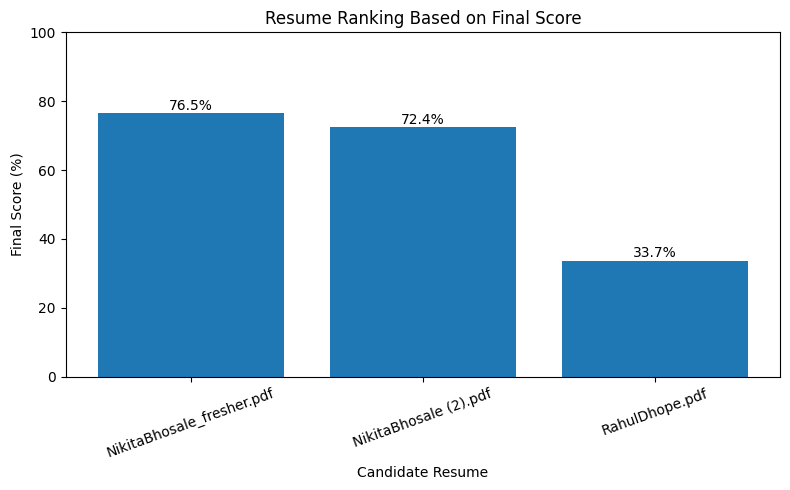

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Candidate"],
    results_df["Final Score"]
)

plt.title("Resume Ranking Based on Final Score")
plt.xlabel("Candidate Resume")
plt.ylabel("Final Score (%)")
plt.ylim(0, 100)

plt.xticks(rotation=20)

for i, score in enumerate(results_df["Final Score"]):
    plt.text( i, score + 1, f"{score:.1f}%", ha="center" )

plt.tight_layout()
plt.show()

In [20]:
for rank, row in results_df.iterrows():
    print("=" * 60)
    print(f"Rank: {rank}")
    print(f"Candidate: {row['Candidate']}")
    print(f"Final Score: {row['Final Score']}%")
    print(f"Status: {row['Status']}")

    print("\nTop Skills Found:")
    if row["Matched Skills"]:
        print(row["Matched Skills"])
    else:
        print("No required skills found")

    print("\nMissing Skills:")
    if row["Missing Skills"]:
        print(row["Missing Skills"])
    else:
        print("No missing skills")

    print()

Rank: 1
Candidate: NikitaBhosale_fresher.pdf
Final Score: 76.55%
Status: Selected for Interview

Top Skills Found:
python, sql, excel, power bi, tableau, pandas, numpy, data analysis, data visualization, statistics, machine learning, communication

Missing Skills:
problem solving

Rank: 2
Candidate: NikitaBhosale (2).pdf
Final Score: 72.4%
Status: Shortlisted

Top Skills Found:
python, sql, excel, power bi, tableau, pandas, numpy, data analysis, data visualization, statistics, machine learning

Missing Skills:
communication, problem solving

Rank: 3
Candidate: RahulDhope.pdf
Final Score: 33.66%
Status: Rejected

Top Skills Found:
python, sql, power bi, tableau, data visualization

Missing Skills:
excel, pandas, numpy, data analysis, statistics, machine learning, communication, problem solving



In [21]:
display(results_df[["Candidate","Final Score","Matched Skills","Missing Skills","Status"]])

,Candidate,Final Score,Matched Skills,Missing Skills,Status
Rank,,,,,
1,NikitaBhosale_fresher.pdf,76.55,"python, sql, excel, power bi, tableau, pandas,...",problem solving,Selected for Interview
2,NikitaBhosale (2).pdf,72.40,"python, sql, excel, power bi, tableau, pandas,...","communication, problem solving",Shortlisted
3,RahulDhope.pdf,33.66,"python, sql, power bi, tableau, data visualiza...","excel, pandas, numpy, data analysis, statistic...",Rejected
